In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import ModelCheckpoint


from network import NetCNN1D, NetCNN2D_CSP

from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold,  StratifiedShuffleSplit

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd
import pickle
import tqdm, logging, warnings

import train_evaluate



# Filter out info and warnings from TensorFlow
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')


config = Config()




# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = [['CLeft'], ['CRight']]
config.session_type = 'S3'


config.test_session = 9 # 3, 7, 9


config.t_start = 0 
config.t_end = 3.0

config.window_size = 2.0




config.n_csp_components = 3


# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']

config.model_type == '2D'




################# Changed in Adaptation #################


config.epochs = 100 #700 # 100
config.batch_size = 32

config.stride = 0.25

config.n_splits = 5
config.val_size = 0.2


config.learning_rate = 2e-3 #2e-4
config.label_smoothing = 0.05
config.weight_decay = 2e-5


0it [00:00, ?it/s]

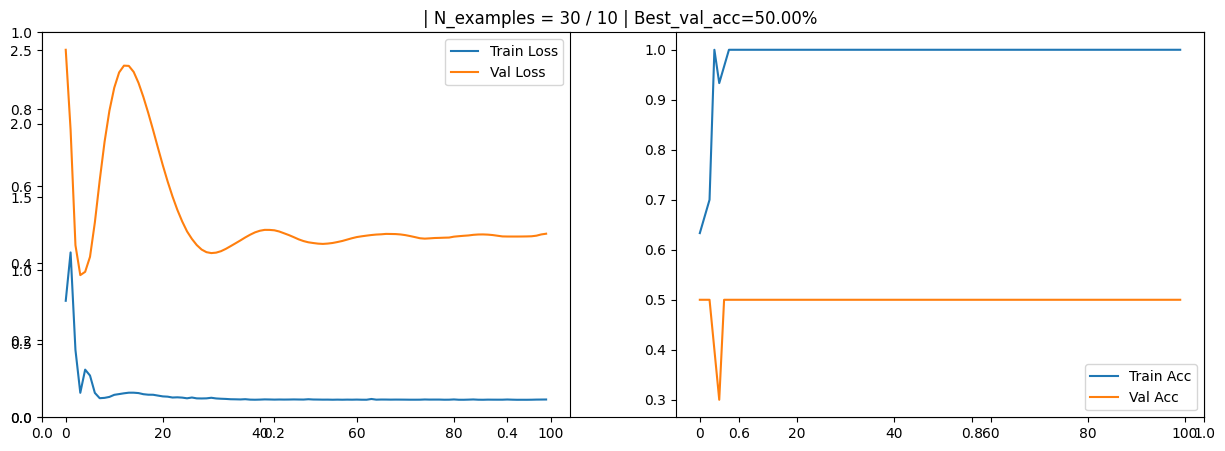

1it [00:10, 10.50s/it]

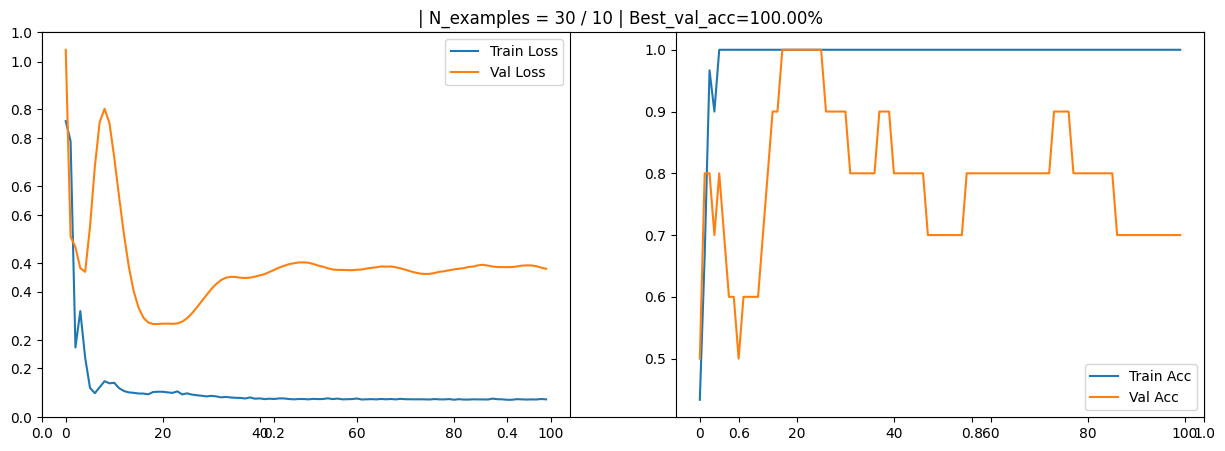

2it [00:19,  9.43s/it]

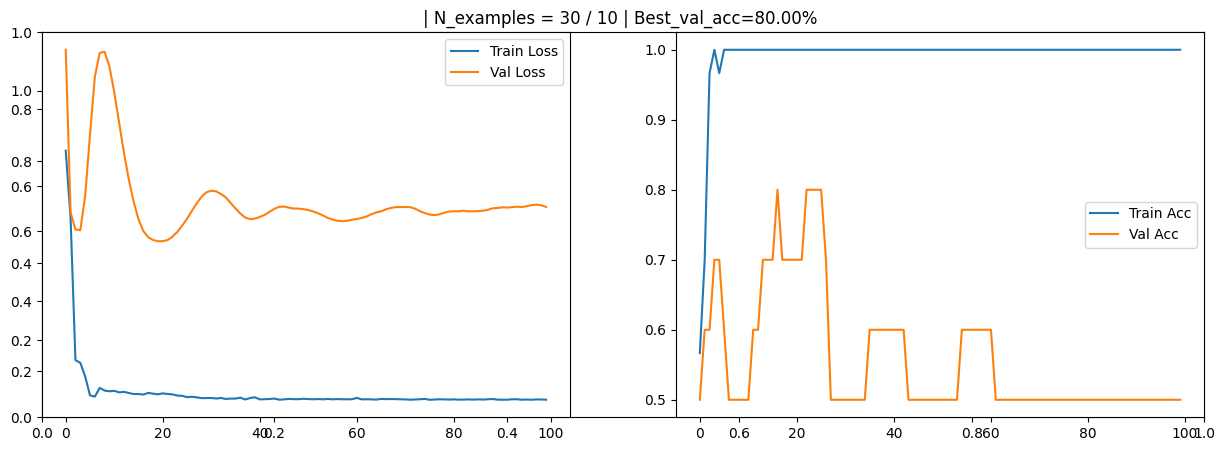

3it [00:27,  9.00s/it]

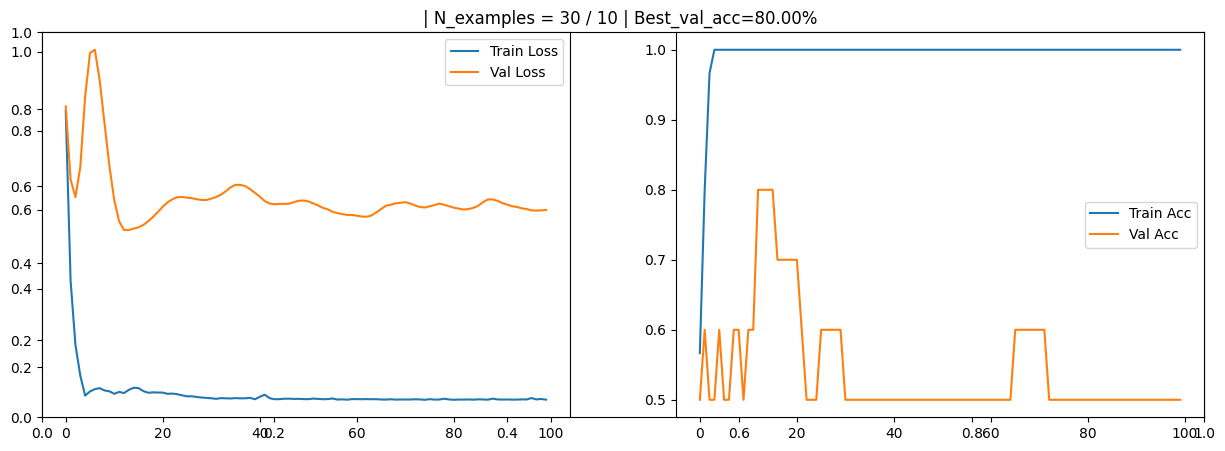

4it [00:36,  9.06s/it]

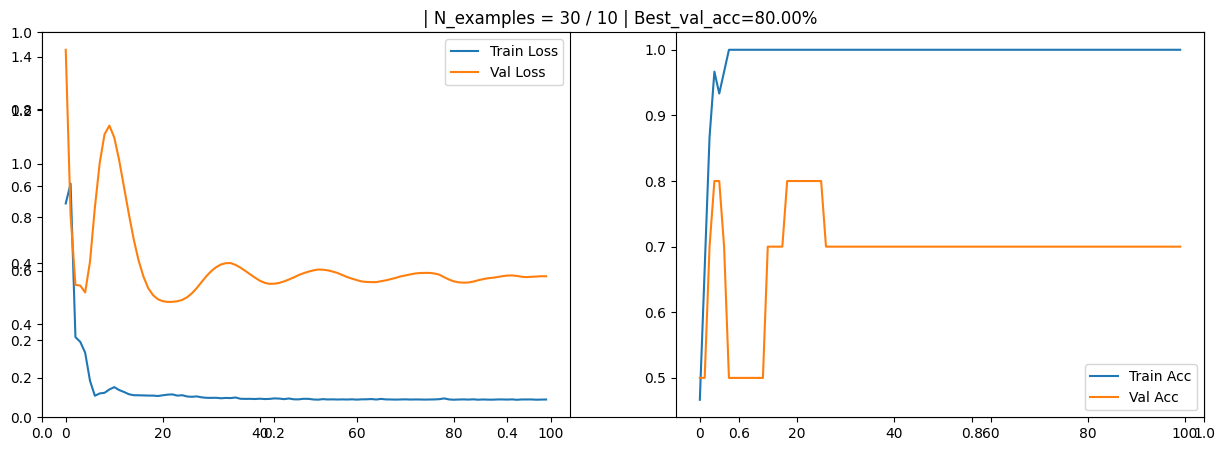

5it [00:45,  9.14s/it]




Average Best Validation accuracy = 100.00% +- 0.0





In [2]:
X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')

#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=config.n_splits, test_size=config.val_size, random_state=0)

shuffle_indices = np.random.permutation(len(y))
X = X[shuffle_indices]
y = y[shuffle_indices]


val_accs_allFolds = []
for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):

    model = tf.keras.models.load_model(os.path.join('saved_models', 'best_model.tf'))

    with open(os.path.join('saved_models', 'csp.pkl'), 'rb') as f:
        csp_trained = pickle.load(f)

    for layer in model.layers:
        layer.trainable = False
        if layer.name in ['fc']:
            layer.trainable = True



    X_train, Y_train = X[train_index],  y[train_index]
    X_valid, Y_valid = X[valid_index], y[valid_index]

    _, _, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, csp = csp_trained, plot_graphs=True, train=False)


    val_accs_allFolds.append(val_acc)


print("\n\n ========================================= \n")
print(f"Average Best Validation accuracy = {100*np.mean(val_accs_allFolds):.2f}% +- {100*np.std(val_accs_allFolds):.1f}")
print("\n\n ========================================= \n")

0it [00:00, ?it/s]

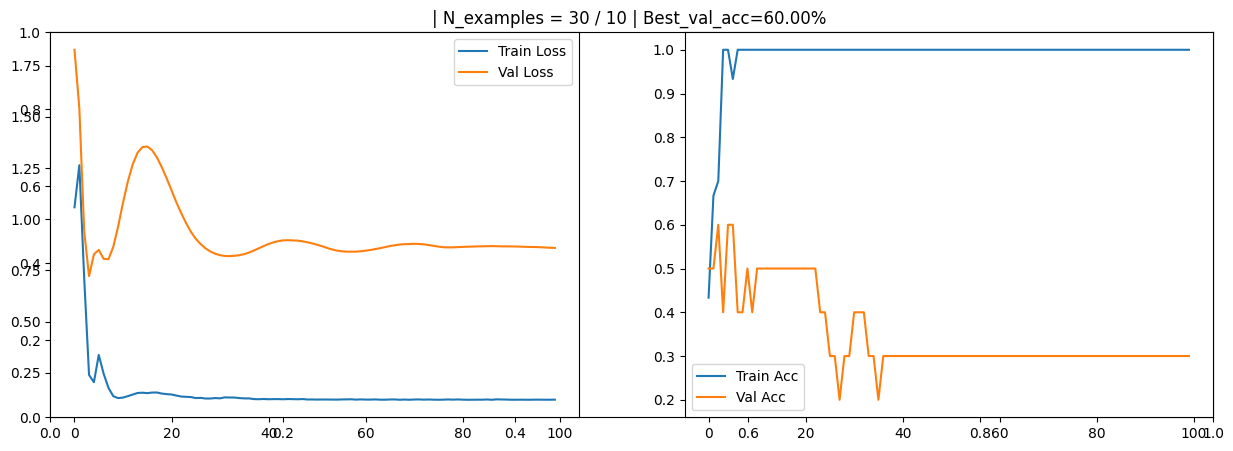

1it [00:09,  9.40s/it]

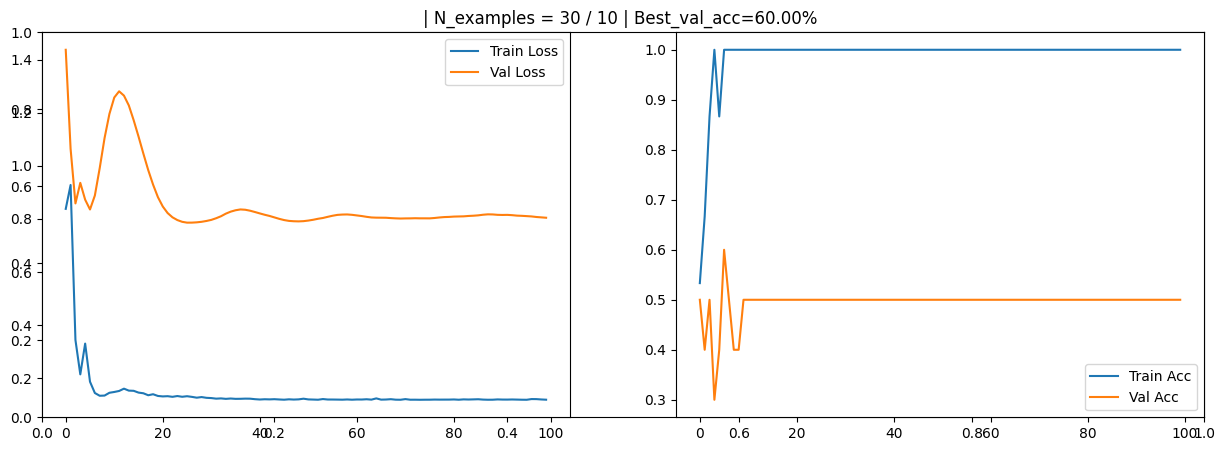

2it [00:17,  8.87s/it]

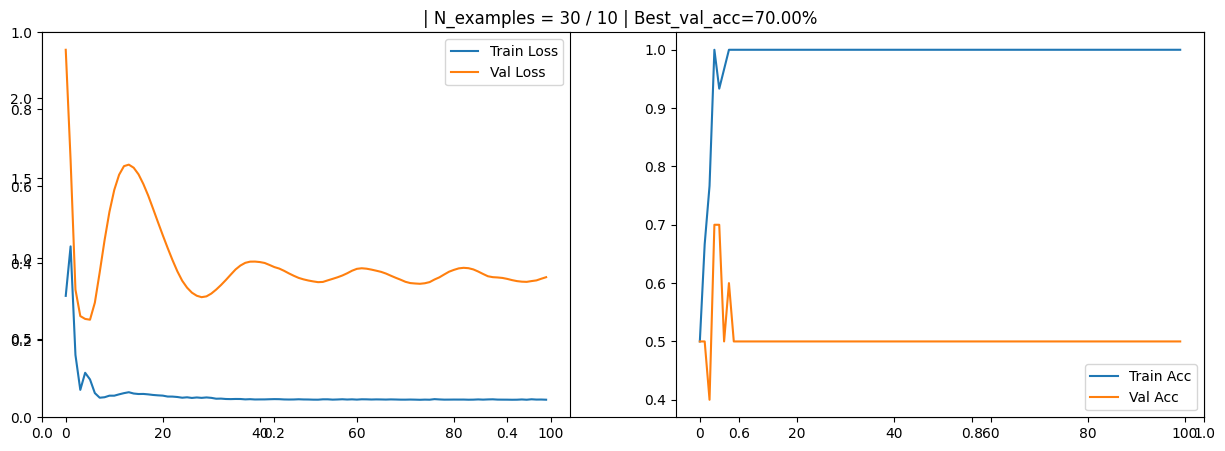

3it [00:26,  8.83s/it]

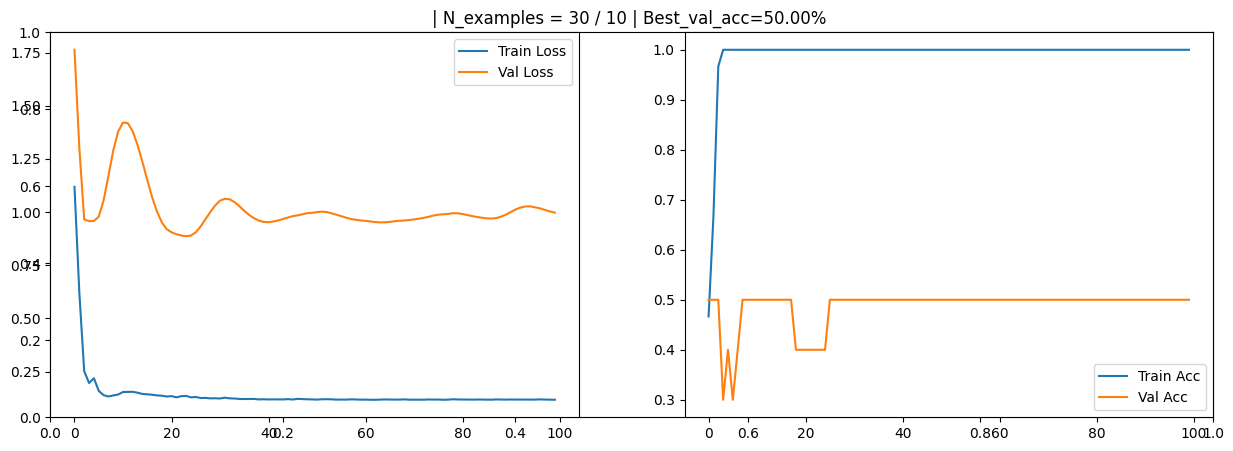

4it [00:35,  8.82s/it]

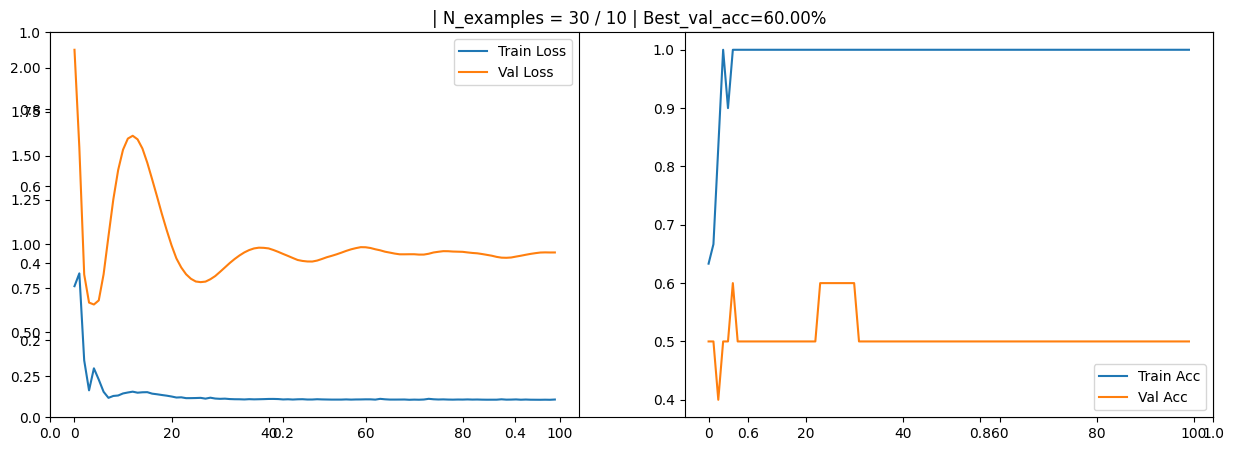

5it [00:44,  8.97s/it]




Average Best Validation accuracy = 100.00% +- 0.0





In [3]:
X, y = dataset_NewEEG.session_dataset(config, f'I{config.test_session:02d}')

#crossValidation_KF = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
crossValidation_KF = StratifiedShuffleSplit(n_splits=config.n_splits, test_size=config.val_size, random_state=0)

shuffle_indices = np.random.permutation(len(y))
X = X[shuffle_indices]
y = y[shuffle_indices]


val_accs_allFolds = []
for train_index, valid_index in tqdm.tqdm(crossValidation_KF.split(X,y)):

    model = tf.keras.models.load_model(os.path.join('saved_models', 'best_model.tf'))

    for layer in model.layers:
        layer.trainable = False
        if layer.name in ['fc']:
            layer.trainable = True



    X_train, Y_train = X[train_index],  y[train_index]
    X_valid, Y_valid = X[valid_index], y[valid_index]

    _, _, val_acc = train_evaluate.train_evalute(config, X_train, Y_train, X_valid, Y_valid, model, csp = None, plot_graphs=True, train=False)


    val_accs_allFolds.append(val_acc)


print("\n\n ========================================= \n")
print(f"Average Best Validation accuracy = {100*np.mean(val_accs_allFolds):.2f}% +- {100*np.std(val_accs_allFolds):.1f}")
print("\n\n ========================================= \n")